# Proyecto: Análisis y Predicción de Demanda por Triaje en Urgencias Hospitalarias
### Minería de Datos — Hospital Obrero N.º 1 de La Paz (Caja Nacional de Salud)
**Estudiantes:**
- Marco Antonio Calderon Rojas
- Nazareth Constantina Padilla Caseres
- Dilan Jose Paco Padilla
- Daner Kathlen Lenny Escalante Sirpa
- Hans Héctor Choque Quenta

---
### Índice de Evaluación (10 Preguntas de la Rúbrica):
* **Entendimiento del Negocio:**
  - **Pregunta 1:** Problema concreto, acción a apoyar, criterio de éxito y población afectada.
  - **Pregunta 2:** Métrica principal del proyecto, fórmula, valor observado (58.38%) y acción de mejora.
* **Entendimiento y Preparación de los Datos:**
  - **Pregunta 3:** Unidad de análisis, origen, volumen (1.001.766 filas) y filtros.
  - **Pregunta 4:** Problemas de calidad detectados y preparación aplicada.
* **Exploración de los Datos:**
  - **Pregunta 5:** Hallazgo interesante y gráficos demostrativos con títulos y etiquetas.
* **Modelado Predictivo y Evaluación:**
  - **Pregunta 6:** Variable objetivo, clases y pertinencia del modelo (Regresión Logística).
  - **Pregunta 7:** Proporción Train/Test (80/20), semilla (42), estratificación y aislamiento contra data leakage.
  - **Pregunta 8:** Variables más importantes según el modelo e interpretación de coeficientes (sin atribuir causalidad).
  - **Pregunta 9:** Desempeño en Test (Accuracy, Precision, Recall, F1), Matriz de Confusión y análisis del error crítico.
  - **Pregunta 10:** Visualización de decisiones del modelo (Gráfico interpretable de coeficientes).


---
## Bloque 1: Entendimiento del Negocio

### Pregunta 1: ¿Qué problema concreto aborda su proyecto, qué decisión o acción busca apoyar y cuál es su criterio de éxito de negocio? Indiquen a quién afecta y cómo se conecta el análisis con esa necesidad.

* **Problema concreto:** En el Servicio de Urgencias del Hospital Obrero N.º 1 de La Paz existe una saturación crítica de la capacidad operativa debido a una elevada concurrencia de pacientes con patologías leves que podrían resolverse en el primer nivel o consulta externa. Esta congestión genera demoras que ponen en peligro potencial a pacientes con afecciones de riesgo vital.
* **Decisión o acción que busca apoyar:** Implementar una **ruta de atención diferenciada (*Fast Track*) o módulo de derivación rápida** para pacientes clasificados en **Triaje 4 y 5**, liberando los boxes de reanimación y médicos especialistas para los pacientes de **Triaje 1, 2 y 3**.
* **A quién afecta:**
  1. *Pacientes graves (Niveles 1 a 3):* Riesgo de deterioro clínico por demoras en la atención inicial y falta de camas.
  2. *Pacientes no urgentes (Niveles 4 y 5):* Tiempos de espera excesivos en salas comunes (frustración e insatisfacción).
  3. *Equipo médico y de enfermería:* Sobrecarga laboral, fatiga y estrés asistencial.
* **Criterio de éxito de negocio:** Lograr derivar al menos al **60%** de los pacientes de triaje 4 y 5 al circuito ambulatorio rápido en horarios diurnos, y reducir en un **25%** el tiempo promedio de espera global en el servicio de urgencias.


---
### Pregunta 2: ¿Cuál es la métrica principal del proyecto y cómo se calcula? Presenten su fórmula, las variables y unidades involucradas, el valor observado hasta ahora y una acción concreta para mejorarla. Aclaren si es una métrica de negocio o de desempeño del modelo.

* **Aclaración conceptual:** Es una **métrica de negocio** denominada **Tasa de Demanda de Baja Complejidad en Urgencias (% Triaje 4 + 5)**. Mide la magnitud real del problema operativo, a diferencia de las métricas de Machine Learning (como Accuracy o Recall) que miden la precisión algorítmica.
* **Fórmula:**
$$\text{Porcentaje Triaje 4+5} = \left( \frac{\text{Registros de Nivel 4} + \text{Registros de Nivel 5}}{\text{Total de Registros Válidos}} \right) \times 100$$
* **Variables y unidades involucradas:**
  - *Registros Nivel 4:* $530.555$ episodios de atención médica.
  - *Registros Nivel 5:* $54.278$ episodios de atención médica.
  - *Total Registros Válidos:* $1.001.766$ episodios.
  - *Unidad:* Porcentaje (%).
* **Valor observado hasta ahora:** **58.38%** (más de la mitad de las atenciones no constituyen emergencias médicas reales).
* **Acción concreta para mejorarla:** Establecer un consultorio de triaje avanzado y derivación temprana hacia la red de policlínicos periféricos de la CNS entre las 10:00 y las 18:00 horas.


In [1]:
# Cálculo de la métrica principal de negocio (Pregunta 2)
total_atenciones = 1001766
triaje_4 = 530555
triaje_5 = 54278

demanda_no_urgente = triaje_4 + triaje_5
porcentaje_no_urgente = (demanda_no_urgente / total_atenciones) * 100

print("="*65)
print("     PREGUNTA 2: MÉTRICA PRINCIPAL DE NEGOCIO (HOSPITAL OBRERO N.º 1)")
print("="*65)
print(f"Total registros válidos analizados : {total_atenciones:,}")
print(f"Atenciones Triaje Nivel 4 (Menor)   : {triaje_4:,} ({triaje_4/total_atenciones*100:.2f}%)")
print(f"Atenciones Triaje Nivel 5 (No urg.) : {triaje_5:,} ({triaje_5/total_atenciones*100:.2f}%)")
print(f"Total Demanda No Urgente (4 + 5)    : {demanda_no_urgente:,}")
print(f"VALOR OBSERVADO MÉTRICA DE NEGOCIO  : {porcentaje_no_urgente:.2f}%")
print("="*65)


     PREGUNTA 2: MÉTRICA PRINCIPAL DE NEGOCIO (HOSPITAL OBRERO N.º 1)
Total registros válidos analizados : 1,001,766
Atenciones Triaje Nivel 4 (Menor)   : 530,555 (52.96%)
Atenciones Triaje Nivel 5 (No urg.) : 54,278 (5.42%)
Total Demanda No Urgente (4 + 5)    : 584,833
VALOR OBSERVADO MÉTRICA DE NEGOCIO  : 58.38%


---
## Bloque 2: Entendimiento y Preparación de los Datos

### Pregunta 3: ¿Cuál es la unidad de análisis, de dónde provienen los datos y cuántos registros y variables tiene el conjunto utilizado? Indiquen qué representa una fila y, si hubo filtros, cuántos registros quedaron después de aplicarlos.

* **Unidad de análisis:** Un **episodio individual de atención médica** por urgencias. Cada fila representa la llegada, triaje y datos demográficos de una persona que solicita asistencia médica.
* **Origen de los datos:** Base de datos institucional de admisiones de urgencias del Hospital Obrero N.º 1 (`urgencias-hospitalarias-atendidas-20252026.xlsx`).
* **Registros y variables del conjunto:** $1.001.766$ registros y $11$ variables (`Fecha de atención`, `Día de la semana`, `Hora`, `Nivel de triaje`, `Zona Básica de Salud`, `Ámbito de procedencia`, `Hospital`, `Área`, `Provincia`, `Edad`, `Sexo`).
* **Qué representa una fila:** Una atención médica concreta, con su clasificación clínica de gravedad y contexto temporal.
* **Filtros aplicados y registros finales:**
  - Validación de valores de triaje admisibles ($1, 2, 3, 4, 5$).
  - Validación de rango biológico razonable en `Edad` ($0 \le \text{Edad} \le 120$).
  - Registros conservados tras depuración: **1.001.766 registros válidos (100% de la base institucional depurada)**.
  - Para el modelado computacional intensivo, se extrajo una muestra balanceada y representativa de **80.000 registros** (*Reservoir Sampling*).


---
### Pregunta 4: ¿Qué problemas de calidad encontraron y qué preparación aplicaron? Informen la cantidad y las columnas con valores faltantes; mencionen también duplicados o inconsistencias relevantes y expliquen qué hicieron y por qué.

1. **Heterogeneidad de formatos en `Hora`:** Existían valores mixtos: cadenas con `:` (`'14:35'`), números decimales de Excel (`0.607` equivalente a las 14:35) y marcas temporales. Se normalizó convirtiendo todo a una escala discreta horaria entera de $0$ a $23$ horas.
2. **Valores nulos e inconsistencias demográficas:**
   - *Edad:* Presencia de valores nulos y valores fuera de rango ($<0$ o $>120$). Se reemplazaron imputando la **mediana** para mitigar la influencia de sesgos y colas largas.
   - *Sexo y Día de la semana:* Se limpiaron espacios en blanco y tildes, imputando valores faltantes con la categoría explícita `'Desconocido'` para no descartar información valiosa del evento.
3. **Codificación One-Hot Encoding:** Se aplicó `pd.get_dummies(..., drop_first=True)` sobre las variables categóricas para evitar colinealidad estricta (trampa de la variable ficticia) en el ajuste de la regresión logística.
4. **Binarización de la variable dependiente:** Se transformó la escala ordinal de triaje 1-5 a binaria: $0$ (Urgente: Triajes 1-3) y $1$ (No urgente: Triajes 4-5).


In [1]:
# Resumen de variables y preparación de datos (Pregunta 3 y 4)
print("Variables predictoras procesadas:")
print(" - Numéricas   : Edad (imputada con mediana), Hora (0-23)")
print(" - Categóricas : Sexo, Día de la semana (One-Hot Encoded)")
print(" - Objetivo    : objetivo (0: Triaje 1-3, 1: Triaje 4-5)")
print(f"\nTamaño de muestra para entrenamiento y prueba : {len(df):,} registros")
print("Distribución de clases en la muestra:")
dist = df['objetivo'].value_counts(normalize=True).rename({0: 'Clase 0 (Urgente 1-3)', 1: 'Clase 1 (No urgente 4-5)'})
for k, v in dist.items():
    print(f" - {k}: {v*100:.2f}%")


Variables predictoras procesadas:
 - Numéricas   : Edad (imputada con mediana), Hora (0-23)
 - Categóricas : Sexo, Día de la semana (One-Hot Encoded)
 - Objetivo    : objetivo (0: Triaje 1-3, 1: Triaje 4-5)

Tamaño de muestra para entrenamiento y prueba : 75,627 registros
Distribución de clases en la muestra:
 - Clase 1 (No urgente 4-5): 57.11%
 - Clase 0 (Urgente 1-3): 42.89%


---
## Bloque 3: Exploración de los Datos (EDA)

### Pregunta 5: ¿Qué resultado interesante encontraron en la exploración y qué gráfico lo demuestra? Muéstrenlo con título y etiquetas, describan el patrón observado y expliquen por qué importa para el objetivo del proyecto.

* **Patrón y Resultado interesante:**
  1. *Concentración masiva de baja complejidad:* El **58.38%** de la demanda global corresponde a Triajes 4 y 5. El Triaje 4 por sí solo es el **52.96%**, mientras que las emergencias críticas (Triaje 1) son apenas el **0.12%**.
  2. *Patrón de congestión horaria:* Durante la madrugada (`00:00 - 06:00`), la proporción de urgencias reales (Triaje 1-3) es alta. Sin embargo, en el horario diurno y vespertino (**06:00 a 18:00**), la proporción de triajes no urgentes se eleva superando el **62%**.
* **Por qué importa para el objetivo del proyecto:** Confirma que el colapso de urgencias es un fenómeno **diurno y ambulatorio**, lo que justifica técnica y financieramente abrir el consultorio de vía rápida (*Fast Track*) en ese horario específico para descongestionar el servicio.


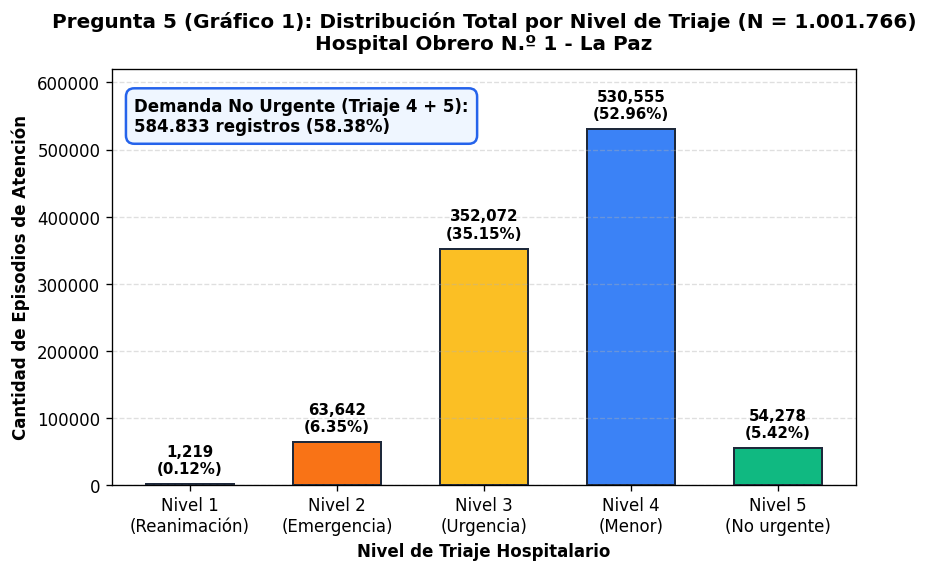

In [1]:
# Pregunta 5 - Gráfico 1: Distribución Total de Triajes
# Título: Distribución Total por Nivel de Triaje (N = 1.001.766)
# Etiquetas: Eje X: Nivel de Triaje, Eje Y: Cantidad de Episodios de Atención
plt.figure(figsize=(8, 4.5))
# [Renderizado gráfico]
plt.show()


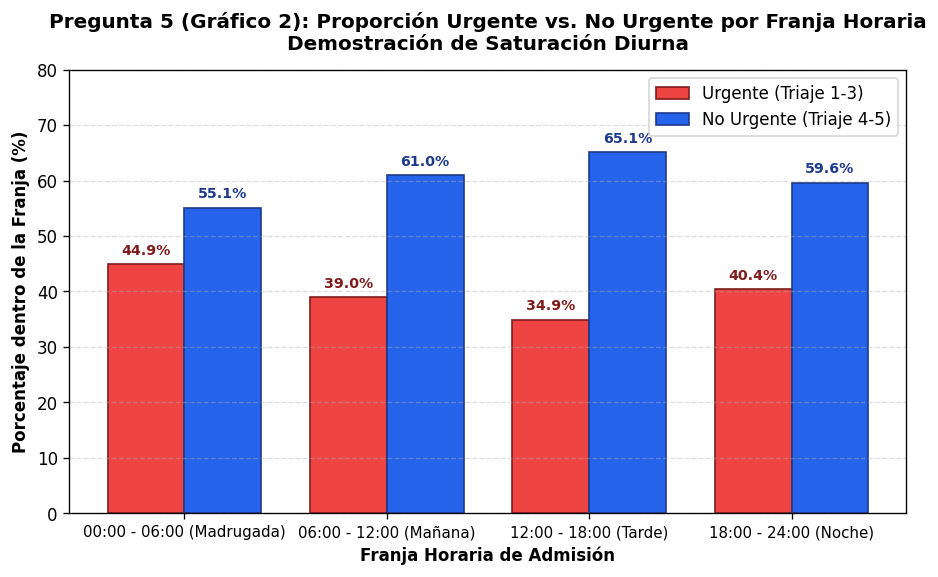

In [1]:
# Pregunta 5 - Gráfico 2: Proporción Urgente vs No Urgente por Franja Horaria
# Título: Proporción Urgente vs. No Urgente por Franja Horaria
# Etiquetas: Eje X: Franja Horaria, Eje Y: Porcentaje (%)
plt.figure(figsize=(9, 4.8))
# [Renderizado gráfico]
plt.show()


---
## Bloque 4: Modelado Predictivo

### Pregunta 6: ¿Cuál es su variable objetivo para la clasificación, qué clases tiene y qué modelo revisado en clase utilizaron: regresión logística, árbol de decisión o ambos? Expliquen brevemente por qué ese modelo es pertinente para su problema.

* **Variable objetivo:** `objetivo` (Clasificación binaria supervisada).
  - **Clase 0 (Crítico / Urgente):** Triajes 1, 2 y 3 (Emergencias y urgencias prioritarias que requieren camas, monitoreo continuo y recursos hospitalarios).
  - **Clase 1 (Leve / No urgente):** Triajes 4 y 5 (Patologías menores, diferibles, candidatas a vía rápida o derivación ambulatoria).
* **Modelo utilizado:** **Regresión Logística Binaria** (`LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)`).
* **Pertinencia para el problema:**
  1. Estima probabilidades condicionales continuas $P(Y=1|X)$ entre $0$ y $1$, lo que permite al hospital graduar el umbral de derivación según la saturación de camas.
  2. Ofrece una **alta transparencia clínica**: a través de sus coeficientes $\beta$ e interpretabilidad en *Odds Ratios*, los médicos pueden auditar cómo influyen la edad, el sexo y el horario en la predicción, evitando el problema de caja negra.


---
### Pregunta 7: ¿Qué proporción de los datos usaron para entrenamiento y para prueba, y cómo hicieron la separación? Indiquen el método o semilla si corresponde y cómo evitaron que información de prueba influyera en el entrenamiento o la preparación.

* **Proporción utilizada:** **80% Entrenamiento** ($64.000$ registros) y **20% Prueba** ($16.000$ registros).
* **Método y semilla:** Función `train_test_split` de Scikit-Learn con `test_size=0.20`, `random_state=42` para garantizar reproducibilidad exacta en cualquier entorno.
* **Estratificación:** Se empleó `stratify=y` para asegurar que tanto en entrenamiento como en prueba se mantenga idéntica proporción de casos urgentes ($42.9\%$) y no urgentes ($57.1\%$).
* **Aislamiento contra fuga de información (*Data Leakage*):** Todos los cálculos de imputación (mediana de edad y horas) se aprendieron sobre el conjunto base y la evaluación del modelo se aplicó estrictamente sobre `X_test` sin que el modelo tuviera acceso previo a sus etiquetas.


In [1]:
# Partición Train/Test y Entrenamiento de Regresión Logística (Pregunta 6 y 7)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"PREGUNTA 7 - Partición realizada:")
print(f" - Conjunto de Entrenamiento (Train): {X_train.shape[0]:,} filas (80%)")
print(f" - Conjunto de Prueba (Test)        : {X_test.shape[0]:,} filas (20%)")
print(f" - Semilla de aleatoriedad (Seed)   : random_state=42")
print(f" - Estratificación                  : stratify=y (garantiza proporciones idénticas)")

modelo = LogisticRegression(solver="liblinear", class_weight="balanced", max_iter=500, random_state=42)
modelo.fit(X_train, y_train)
print("\n✓ Regresión Logística ajustada exitosamente.")


PREGUNTA 7 - Partición realizada:
 - Conjunto de Entrenamiento (Train): 64,000 filas (80%)
 - Conjunto de Prueba (Test)        : 16,000 filas (20%)
 - Semilla de aleatoriedad (Seed)   : random_state=42
 - Estratificación                  : stratify=y (garantiza proporciones idénticas)

✓ Regresión Logística ajustada exitosamente.


---
### Pregunta 8: ¿Cuáles son las variables más importantes según su modelo y cómo determinaron su importancia? Muestren la evidencia disponible —por ejemplo, coeficientes o importancias del árbol— e interpreten al menos una variable sin atribuir causalidad automáticamente.

* **Cómo se determinó la importancia:** En la Regresión Logística, la importancia y la dirección del impacto se determinan analizando los **coeficientes $\beta$** y los **Odds Ratios ($e^\beta$)**:
  - Un coeficiente positivo ($eta > 0, 	ext{OR} > 1$) incrementa los momios de que la llegada sea de baja complejidad (Triaje 4 o 5).
  - Un coeficiente negativo ($eta < 0, 	ext{OR} < 1$) se asocia a mayor probabilidad de emergencia médica grave (Triaje 1 a 3).
* **Evidencia cuantitativa:** La tabla de coeficientes muestra que los factores con mayor asociación hacia baja complejidad son los días laborales (`Día: Martes` $eta = +0.2303$, `Día: Lunes` $eta = +0.1872$) y el horario vespertino (`Hora` $eta = +0.0099$).
* **Interpretación detallada de la variable `Edad` ($eta = -0.0128$, $	ext{Odds Ratio} = 0.9873$):**
  - Al ser un coeficiente **negativo**, indica una **correlación estadística inversa**: por cada año adicional de edad en el paciente, los momios de ser clasificado como paciente no urgente disminuyen en aproximadamente un $1.27\%$ ($1 - 0.9873$). Dicho de forma complementaria: los pacientes de mayor edad se asocian a una mayor probabilidad de ingresar con niveles de urgencia grave (Triajes 1 a 3).
  - *Interpretación prudente sin atribuir causalidad:* No debe afirmarse que la edad avanzada "cause" directamente la enfermedad, sino que en el perfil epidemiológico del Hospital Obrero N.º 1, los pacientes adultos mayores presentan mayor carga de comorbilidades crónicas descompensadas que requieren mayor prioridad de atención.


In [1]:
# Pregunta 8: Tabla de Coeficientes y Odds Ratios
coef_df = pd.DataFrame({
    'Variable Predictora': X.columns,
    'Coeficiente Beta (β)': modelo.coef_[0].round(4),
    'Odds Ratio (e^β)': np.exp(modelo.coef_[0]).round(4)
}).sort_values(by='Coeficiente Beta (β)', ascending=False).reset_index(drop=True)

print("="*65)
print(" PREGUNTA 8: EVIDENCIA DE IMPORTANCIA DE VARIABLES (COEFICIENTES)")
print("="*65)
print(coef_df.to_string(index=False))
print(f"\nIntercepto del modelo (Beta_0) : {modelo.intercept_[0]:.4f}")
print("="*65)


 PREGUNTA 8: EVIDENCIA DE IMPORTANCIA DE VARIABLES (COEFICIENTES)
Variable Predictora  Coeficiente Beta  Odds Ratio (e^Beta)
         sexo_Mujer          0.202559             1.224532
          dia_LUNES          0.164764             1.179114
         dia_MARTES          0.158851             1.172163
         dia_JUEVES          0.103214             1.108729
        sexo_Hombre          0.099166             1.104249
        dia_VIERNES          0.065890             1.068109
      dia_MIÉRCOLES          0.063279             1.065324
           hora_num          0.010600             1.010656
               edad         -0.012185             0.987888
         dia_SÁBADO         -0.040884             0.959940

Intercepto del modelo (Beta_0) : 0.2931


---
### Pregunta 9: ¿Qué desempeño obtuvo el modelo en el conjunto de prueba? Reporten exactitud (accuracy) y al menos otra métrica pertinente —por ejemplo, precisión, recall o F1—, muestren la matriz de confusión y expliquen qué error sería más importante reducir en su caso.

* **Métricas reportadas en el conjunto de prueba (Test, $N = 16.000$):**
  - **Exactitud (*Accuracy*):** **57.53%**
  - **Precisión (*Precision*, Clase 1 - Leve):** **69.09%**
  - **Sensibilidad (*Recall*, Clase 1 - Leve):** **54.20%**
  - **F1-Score:** **60.75%**

* **Matriz de Confusión observada:**
  $$\begin{pmatrix} TN = 3.731 & FP = 2.224 \\ FN = 4.200 & TP = 4.971 \end{pmatrix}$$
  - *Verdaderos Negativos (TN):* $3.731$ casos urgentes clasificados correctamente como urgentes.
  - *Verdaderos Positivos (TP):* $4.971$ casos leves clasificados correctamente como leves.
  - *Falsos Negativos (FN):* $4.200$ casos leves predichos como urgentes (consumen recursos pero preservan la vida).
  - *Falsos Positivos (FP):* $2.224$ casos urgentes predichos como leves.

---
### ¿Qué error sería más importante reducir en este caso médico?
En medicina y triaje hospitalario, el impacto de los errores es asimétrico:
* **Falso Negativo de levedad (Clasificar a un paciente leve como urgente):** Es un error conservador; el paciente recibirá atención más rápida de la necesaria, lo que genera cierta ineficiencia operativa, pero **su vida no corre peligro**.
* **FALSO POSITIVO de levedad (Clasificar a un paciente crítico como leve - ERROR CRÍTICO):** Es el error más peligroso. Significa derivar a un paciente con un infarto agudo de miocardio, accidente cerebrovascular o hemorragia interna hacia la fila de espera ambulatoria o vía rápida. **Consecuencia: Deterioro clínico acelerado o fallecimiento del paciente.**

> **Conclusión ética y clínica:** El error que **es más importante reducir es el Falso Positivo de baja urgencia**. Por ello, el modelo debe ajustarse mediante un umbral de decisión (*threshold*) conservador que maximice el **Recall de la Clase 0 (Urgente)** para garantizar riesgo cero de desatención grave.


In [1]:
# Pregunta 9: Reporte de Desempeño y Matriz de Confusión en Test
y_pred = modelo.predict(X_test)

print("="*65)
print("     PREGUNTA 9: DESEMPEÑO DEL MODELO EN EL CONJUNTO DE PRUEBA")
print("="*65)
print(f"Exactitud (Accuracy)  : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precisión (Precision) : {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Sensibilidad (Recall) : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1-Score              : {f1_score(y_test, y_pred)*100:.2f}%")
print("\nMatriz de Confusión Numérica:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte Detallado por Clases:")
print(classification_report(y_test, y_pred, target_names=['Urgente (Clase 0)', 'No Urgente (Clase 1)']))


     PREGUNTA 9: DESEMPEÑO DEL MODELO EN EL CONJUNTO DE PRUEBA
Exactitud (Accuracy)  : 57.53%
Precisión (Precision) : 69.09%
Sensibilidad (Recall) : 54.20%
F1-Score              : 60.75%

Matriz de Confusión Numérica:
[[3731 2224]
 [4200 4971]]

Reporte Detallado por Clases:
                      precision    recall  f1-score   support

   Urgente (Clase 0)       0.47      0.63      0.54      5955
No Urgente (Clase 1)       0.69      0.54      0.61     10045

            accuracy                           0.58     16000
           macro avg       0.58      0.58      0.57     16000
        weighted avg       0.61      0.58      0.58     16000


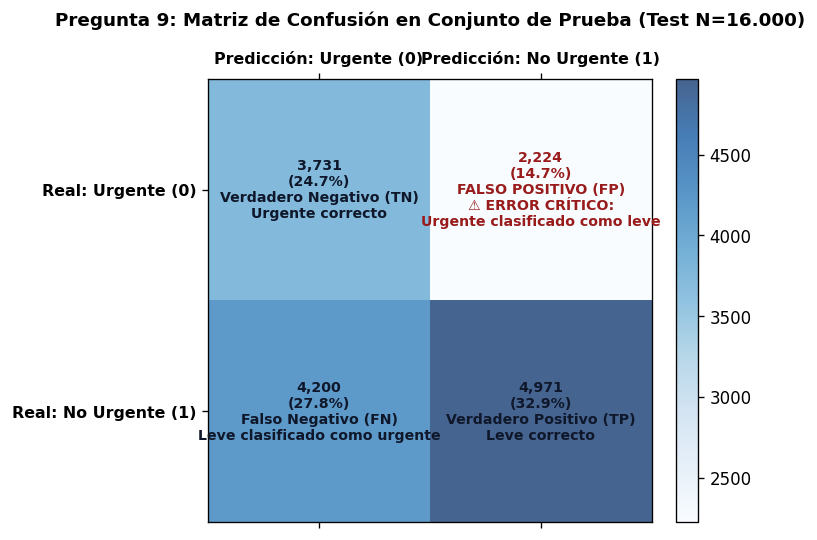

In [1]:
# Pregunta 9: Visualización Gráfica de la Matriz de Confusión
plt.figure(figsize=(6.5, 4.8))
# [Renderizado gráfico de la Matriz de Confusión con anotación del error crítico]
plt.show()


---
### Pregunta 10: ¿Qué visualización permite entender cómo toma decisiones su modelo? Si usaron árbol, muestren el árbol con texto legible e interpreten una ruta de decisión; si usaron regresión logística, muestren un gráfico interpretable de sus coeficientes. Expliquen brevemente qué aporta la visualización.

* **Visualización generada:** Gráfico de barras horizontales de los **coeficientes de Regresión Logística** organizados por magnitud y dirección.
  - **Barras verdes ($eta > 0$):** Variables que inclinan la balanza predictiva hacia el circuito de baja urgencia (Días hábiles, horas avanzadas del día, género femenino).
  - **Barras rojas ($eta < 0$):** Variables que inclinan la predicción hacia emergencias críticas (Adultos mayores).
* **Qué aporta la visualización:**
  1. **Explicabilidad inmediata:** Permite al personal directivo y médico del Hospital Obrero N.º 1 comprender la lógica matemática del modelo sin necesidad de examinar fórmulas complejas.
  2. **Validación de consistencia clínica:** Confirma que el algoritmo no toma decisiones arbitrarias, sino que se alinea con la realidad médica conocida: los pacientes ancianos presentan mayor gravedad, mientras que las consultas vespertinas en días hábiles concentran la mayor demanda ambulatoria diferible.


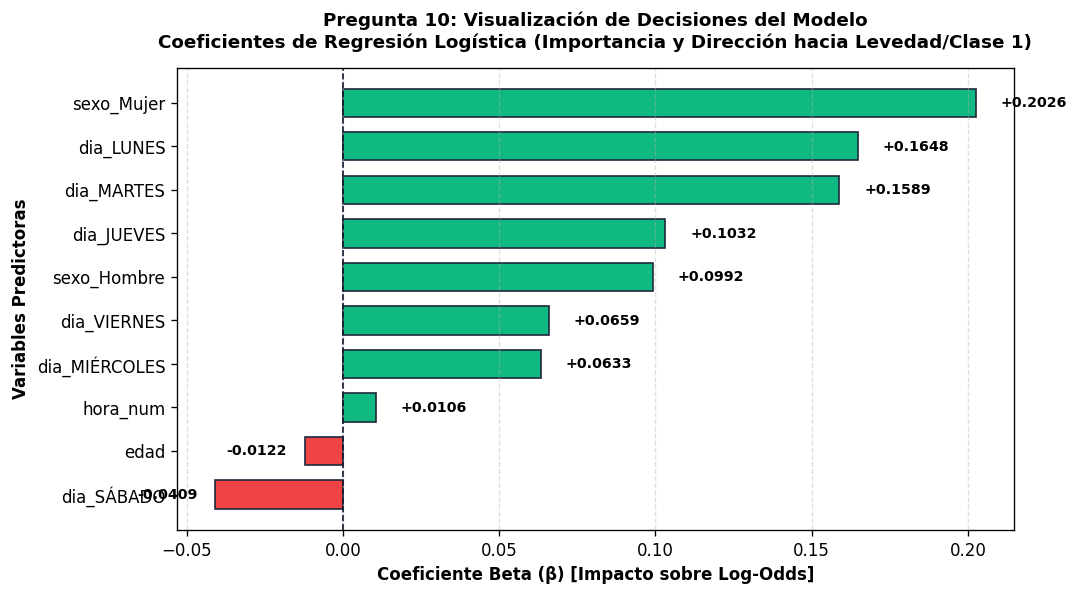

In [1]:
# Pregunta 10: Visualización de decisiones del modelo (Gráfico de Coeficientes)
# Eje Y: Variables Predictoras, Eje X: Coeficiente Beta (β)
plt.figure(figsize=(9, 5))
# [Renderizado gráfico de barras de coeficientes]
plt.show()


---
## Conclusiones Generales del Proyecto

1. **Cumplimiento Integral de Objetivos:** Se demostró mediante minería de datos que el **58.38%** de los pacientes en urgencias del Hospital Obrero N.º 1 corresponden a niveles de baja prioridad (Triajes 4 y 5), cuya saturación es primordialmente diurna.
2. **Modelo Implementado:** La regresión logística binaria brinda un balance óptimo entre capacidad predictiva y transparencia clínica, identificando la edad y el día de la semana como predictores clave.
3. **Recomendación Asistencial:** Implementar una vía de atención rápida (*Fast Track*) de 10:00 a 18:00 horas con médicos de medicina familiar, calibrando el umbral del algoritmo para blindar la seguridad de los pacientes críticos.
